# LLM serving performance and wall energy

## 1. Load experiments

In [119]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 60)
plt.style.use("ggplot")

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "run_benchmark.py").is_file()), None)
if PROJECT_ROOT is None: raise FileNotFoundError("Open the notebook from the benchmark repository root or notebooks/")

RESULTS = PROJECT_ROOT / "results"
PROMETHEUS_LABELS = ("shelly-gpu", "shelly-gpu-node")
LLM_MODEL_NAMES = ("llama3.2:3b", "gemma4:e2b")
LLM_MODEL_COLORS = {"llama3.2:3b": "#2676af", "gemma4:e2b": "#df8020"}
print("Results directory:", RESULTS)


Results directory: /home/toporek3112/Projects/llm_benchmarks/performance/results


In [ ]:
## Read all run.json and benchmark.json files under results/<model>/<run-id>/ and summarize them in a DataFrame

def read_json(path):
  return json.loads(path.read_text()) if path.exists() else {}


def option(args, flag, default=np.nan):
  try:
    return args[args.index(flag) + 1]
  except (ValueError, IndexError):
    return default


def as_float(value):
  try:
    return float(value)
  except (TypeError, ValueError):
    return np.nan


def parse_power(payload):
  rows = []
  if payload.get("status") != "success" or payload.get("data", {}).get("resultType") != "matrix":
    return pd.DataFrame(columns=["sensor", "epoch", "watts"])
  for series in payload["data"].get("result", []):
    sensor = series.get("metric", {}).get("sensor")
    for stamp, value in series.get("values", []):
      watts = as_float(value)
      if sensor in PROMETHEUS_LABELS and np.isfinite(watts):
        rows.append((sensor, float(stamp), watts))
  return pd.DataFrame(rows, columns=["sensor", "epoch", "watts"])


def placement(meta):
  candidates = meta.get("model_preparation", {}).get("state_before_benchmark", {}).get("match", [])
  model = candidates[0] if candidates else {}
  size, vram = as_float(model.get("size")), as_float(model.get("size_vram"))
  fraction = vram / size if np.isfinite(size) and size > 0 and np.isfinite(vram) else np.nan
  return model.get("digest"), model.get("details", {}).get("quantization_level"), fraction

runs, rows, request_rows = {}, [], []

for path in sorted(RESULTS.glob("*/*/run.json")):
  folder = path.parent
  key = str(folder.relative_to(RESULTS))
  meta = read_json(path)
  bench = read_json(folder / "benchmark.json")
  power = parse_power(read_json(folder / "shelly-power.json"))
  runs[key] = {"meta": meta, "bench": bench, "power": power}
  cmd = meta.get("command", [])
  lengths = bench.get("output_lens", [])
  inputs = bench.get("input_lens", [])
  ttfts = bench.get("ttfts", [])
  itls = bench.get("itls", [])
  starts = bench.get("start_times", [])
  digest, quant, gpu_fraction = placement(meta)
  rps = as_float(option(cmd, "--request-rate", bench.get("request_rate")))
  mode = meta.get("start_mode", "unknown")
  scenario = meta.get("scenario") or f"legacy-{mode}-rps-{rps:g}"
  duration = as_float(bench.get("duration", bench.get("benchmark_duration")))
  prompts = as_float(option(cmd, "--num-prompts", bench.get("num_prompts")))

  rows.append({
    "run": key, "campaign": meta.get("campaign_id") or "unlabeled",
    "replicate": meta.get("replicate"), "scenario": scenario,
    "status": meta.get("status"), "model": meta.get("served_model"),
    "mode": mode, "deployment": meta.get("deployment"),
    "hardware": meta.get("hardware"), "client_host": meta.get("client_host"),
    "backend": meta.get("llm_backend"), "server": meta.get("llm_url"),
    "model_digest": digest, "quantization": quant, "gpu_fraction": gpu_fraction,
    "tokenizer": meta.get("tokenizer"),
    "offered_rps": rps,
    "max_concurrency": as_float(option(cmd, "--max-concurrency")),
    "reported_peak_concurrency": as_float(bench.get("max_concurrent_requests")),
    "input_target": as_float(option(cmd, "--random-input-len")),
    "output_cap": as_float(option(cmd, "--random-output-len")),
    "temperature": as_float(option(cmd, "--temperature")),
    "seed": as_float(option(cmd, "--seed")),
    "requested": prompts, "completed": as_float(bench.get("completed")),
    "failed": as_float(bench.get("failed")), "duration_s": duration,
    "achieved_rps": as_float(bench.get("request_throughput")),
    "output_tok_s": as_float(bench.get("output_throughput")),
    "output_tokens": as_float(bench.get("total_output_tokens")),
    "input_tokens": as_float(bench.get("total_input_tokens")),
    "output_p50_tokens": float(np.median(lengths)) if lengths else np.nan,
    "output_p05_tokens": float(np.percentile(lengths, 5)) if lengths else np.nan,
    "input_p50_tokens": float(np.median(inputs)) if inputs else np.nan,
    "mean_ttft_ms": as_float(bench.get("mean_ttft_ms")),
    "p95_ttft_ms": as_float(bench.get("p95_ttft_ms")),
    "mean_tpot_ms": as_float(bench.get("mean_tpot_ms")),
    "p95_tpot_ms": as_float(bench.get("p95_tpot_ms")),
    "p95_e2el_ms": as_float(bench.get("p95_e2el_ms")),
    "mean_e2el_ms": as_float(bench.get("mean_e2el_ms")),
    "cold_load_s": as_float(meta.get("model_preparation", {}).get("cold_load_wall_seconds")),
    "step_s": as_float(meta.get("power_step_seconds", 10)),
    "power_points": {s: int((power["sensor"] == s).sum()) for s in PROMETHEUS_LABELS},
    "ttft_count": len(ttfts), "request_array_count": len(lengths),
    "started": pd.to_datetime(meta.get("created_at_utc"), utc=True, errors="coerce"),
  })
  for i in range(max(len(lengths), len(ttfts))):
    if i >= len(lengths) or i >= len(ttfts):
      continue
    intervals = itls[i] if i < len(itls) and isinstance(itls[i], list) else []
    ttft = as_float(ttfts[i])
    request_rows.append({
      "run": key, "model": meta.get("served_model"), "scenario": scenario,
      "index": i, "input_tokens": inputs[i] if i < len(inputs) else np.nan,
      "output_tokens": lengths[i], "ttft_ms": ttft * 1000,
      "tpot_ms": np.mean(intervals) * 1000 if intervals else np.nan,
      "e2el_ms": (ttft + sum(intervals)) * 1000 if np.isfinite(ttft) else np.nan,
      "interval_count": len(intervals),
      "relative_start_s": starts[i] - starts[0] if len(starts) > i else np.nan,
      "error": bench.get("errors", [])[i] if i < len(bench.get("errors", [])) else "",
    })

if not rows:
  raise FileNotFoundError(f"No run.json found under {RESULTS}/<model>/<run-id>/")
summary = pd.DataFrame(rows).set_index("run").sort_values("started")
requests = pd.DataFrame(request_rows)
display(summary[["campaign", "replicate", "scenario", "status", "model", "mode",
  "requested", "completed", "failed", "duration_s", "offered_rps",
  "output_p50_tokens", "quantization", "gpu_fraction"]])


## 2. Check the experiment before comparing it

`status=complete`, zero failures, and matching request counts are required for performance. For energy, both PROMETHEUS_LABELS must bracket the serving phase, have no large gaps, and span at least two minutes with at least 12 intervals. The runner's Prometheus timestamps are evaluation times, so these checks do not make an estimate exact. Flag partial GPU residency and mixed digests/quantizations when interpreting model differences.

The example reports peak concurrency 3 despite `--max-concurrency 1`. That mismatch is shown below as a diagnostic; do not use the reported peak as evidence that the configured client limit was enforced or violated until its implementation is checked.


In [ ]:
def phase(meta, bench):
  start = as_float(meta.get("markers", {}).get("main_start_marker_epoch"))
  duration = as_float(bench.get("duration", bench.get("benchmark_duration")))
  return (start, start + duration) if np.isfinite(start) and np.isfinite(duration) else (np.nan, np.nan)


def integrate_sensor(power, sensor, start, end, step):
  # Integrate bounded evaluated watts with linear edge interpolation.
  frame = power.loc[power["sensor"] == sensor].sort_values("epoch")
  frame = frame.drop_duplicates("epoch", keep="last")
  invalid = {"wh": np.nan, "samples_in_phase": 0, "largest_gap_s": np.nan,
    "coverage": False, "energy_ok": False}
  if len(frame) < 2 or not np.isfinite(start) or not np.isfinite(end) or end <= start:
    return invalid
  t = frame["epoch"].to_numpy(float)
  p = frame["watts"].to_numpy(float)
  inside = t[(t >= start) & (t <= end)]
  covered = bool(t[0] <= start and t[-1] >= end)
  if not covered:
    return {**invalid, "samples_in_phase": len(inside)}
  bounded = np.r_[start, t[(t > start) & (t < end)], end]
  estimated = np.interp(bounded, t, p)
  wh = float(np.sum(np.diff(bounded) * (estimated[:-1] + estimated[1:]) / 2) / 3600)
  largest_gap = float(np.diff(bounded).max())
  good = (end - start >= 120 and len(inside) >= 12
    and largest_gap <= max(2.5 * step, 25))
  return {"wh": wh, "samples_in_phase": len(inside),
    "largest_gap_s": largest_gap, "coverage": covered, "energy_ok": bool(good)}


energy_rows = []
for key, run in runs.items():
  meta, bench, power = run["meta"], run["bench"], run["power"]
  start, end = phase(meta, bench)
  for sensor in PROMETHEUS_LABELS:
    stats = integrate_sensor(power, sensor, start, end,
      as_float(meta.get("power_step_seconds", 10)))
    energy_rows.append({"run": key, "sensor": sensor, **stats})
energy = pd.DataFrame(energy_rows)
for key, group in energy.groupby("run"):
  summary.loc[key, "wall_wh"] = group["wh"].sum() if group["wh"].notna().all() else np.nan
  summary.loc[key, "energy_ok"] = bool(group["energy_ok"].all() and len(group) == len(PROMETHEUS_LABELS))
  summary.loc[key, "power_min_points"] = int(group["samples_in_phase"].min())
  summary.loc[key, "power_max_gap_s"] = group["largest_gap_s"].max()
summary["energy_ok"] = summary["energy_ok"].map(lambda value: bool(value) if pd.notna(value) else False)
summary["mean_wall_w"] = summary["wall_wh"] * 3600 / summary["duration_s"]
summary["wh_per_request"] = summary["wall_wh"] / summary["completed"]
summary["wh_per_1k_output_tokens"] = summary["wall_wh"] / summary["output_tokens"] * 1000

def quality(row):
  issues = []
  if row["status"] != "complete":
    issues.append(f"status={row['status']}")
  if row["failed"] != 0 or row["completed"] != row["requested"]:
    issues.append("request failures / count mismatch")
  if row["ttft_count"] != row["completed"] or row["request_array_count"] != row["completed"]:
    issues.append("missing request detail")
  if row["output_tokens"] <= 0:
    issues.append("no generated tokens")
  if np.isfinite(row["gpu_fraction"]) and row["gpu_fraction"] < 0.98:
    issues.append("partial GPU residency")
  if (np.isfinite(row["reported_peak_concurrency"])
      and row["reported_peak_concurrency"] > row["max_concurrency"]):
    issues.append("reported peak exceeds concurrency setting; inspect semantics")
  if not row["energy_ok"]:
    issues.append("power too sparse / incomplete")
  return issues


summary["issues"] = summary.apply(quality, axis=1)
summary["performance_ok"] = (
  (summary["status"] == "complete") & (summary["failed"] == 0)
  & (summary["completed"] == summary["requested"])
  & (summary["ttft_count"] == summary["completed"])
  & (summary["output_tokens"] > 0)
)
display(summary[["model", "scenario", "completed", "max_concurrency",
  "reported_peak_concurrency", "gpu_fraction", "model_digest",
  "power_min_points", "power_max_gap_s", "energy_ok", "issues"]])
display(summary.groupby(["model", "scenario"], dropna=False).agg(
  runs=("status", "size"), digests=("model_digest", "nunique"),
  quantizations=("quantization", "nunique"),
  client_hosts=("client_host", "nunique"), servers=("server", "nunique")))


,model,scenario,completed,max_concurrency,reported_peak_concurrency,gpu_fraction,model_digest,power_min_points,power_max_gap_s,energy_ok,issues
run,,,,,,,,,,,
llama3-2-3b/20260924T223519139Z,llama3.2:3b,warm-i256-o64-rps-0.5-c1,200.0,1.0,2.0,1.0,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,40.0,10.0,True,[reported peak exceeds concurrency setting; in...
llama3-2-3b/20260924T224340857Z,llama3.2:3b,warm-i256-o128-rps-0.5-c1,200.0,1.0,3.0,1.0,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,40.0,10.0,True,[reported peak exceeds concurrency setting; in...
llama3-2-3b/20260924T225204509Z,llama3.2:3b,warm-i1024-o64-rps-0.5-c1,200.0,1.0,2.0,1.0,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,41.0,10.0,True,[reported peak exceeds concurrency setting; in...
llama3-2-3b/20260924T230047528Z,llama3.2:3b,warm-i1024-o128-rps-0.5-c1,NaN,1.0,NaN,1.0,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,0.0,NaN,False,"[status=running, request failures / count mism..."


runs  digests  quantizations  \
model       scenario                                                   
llama3.2:3b warm-i1024-o128-rps-0.5-c1     1        1              1   
            warm-i1024-o64-rps-0.5-c1      1        1              1   
            warm-i256-o128-rps-0.5-c1      1        1              1   
            warm-i256-o64-rps-0.5-c1       1        1              1   

                                        client_hosts  servers  
model       scenario                                           
llama3.2:3b warm-i1024-o128-rps-0.5-c1             1        1  
            warm-i1024-o64-rps-0.5-c1              1        1  
            warm-i256-o128-rps-0.5-c1              1        1  
            warm-i256-o64-rps-0.5-c1               1        1

### Select one controlled campaign

The default selects the newest campaign and its deployment, hardware, client, and endpoint. Change these selectors deliberately when comparing a different campaign; do not silently pool experiments from different machines.


In [112]:
SELECT_CAMPAIGN = summary.iloc[-1]["campaign"]
SELECT_DEPLOYMENT = summary.iloc[-1]["deployment"]
SELECT_HARDWARE = summary.iloc[-1]["hardware"]
SELECT_CLIENT_HOST = summary.iloc[-1]["client_host"]
SELECT_SERVER = summary.iloc[-1]["server"]

selected = summary.loc[
  (summary["campaign"] == SELECT_CAMPAIGN)
  & (summary["deployment"] == SELECT_DEPLOYMENT)
  & (summary["hardware"] == SELECT_HARDWARE)
  & (summary["client_host"] == SELECT_CLIENT_HOST)
  & (summary["server"] == SELECT_SERVER)
].copy()
print("Selected campaign:", SELECT_CAMPAIGN, "| runs:", len(selected))
display(selected[["model", "scenario", "mode", "status", "model_digest", "quantization"]])


Selected campaign: 20260924T223519099Z | runs: 4


,model,scenario,mode,status,model_digest,quantization
run,,,,,,
llama3-2-3b/20260924T223519139Z,llama3.2:3b,warm-i256-o64-rps-0.5-c1,warm,complete,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,Q4_K_M
llama3-2-3b/20260924T224340857Z,llama3.2:3b,warm-i256-o128-rps-0.5-c1,warm,complete,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,Q4_K_M
llama3-2-3b/20260924T225204509Z,llama3.2:3b,warm-i1024-o64-rps-0.5-c1,warm,complete,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,Q4_K_M
llama3-2-3b/20260924T230047528Z,llama3.2:3b,warm-i1024-o128-rps-0.5-c1,warm,running,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...,Q4_K_M


## 3. Inspect the phases and request traces

Inspect a representative run before relying on averages. The shaded main phase starts at a log marker and its end is derived from the saved vLLM duration. A few evaluated watts can miss a short spike. Request traces show whether unusually short outputs or one fast/slow first request dominate the run summary.


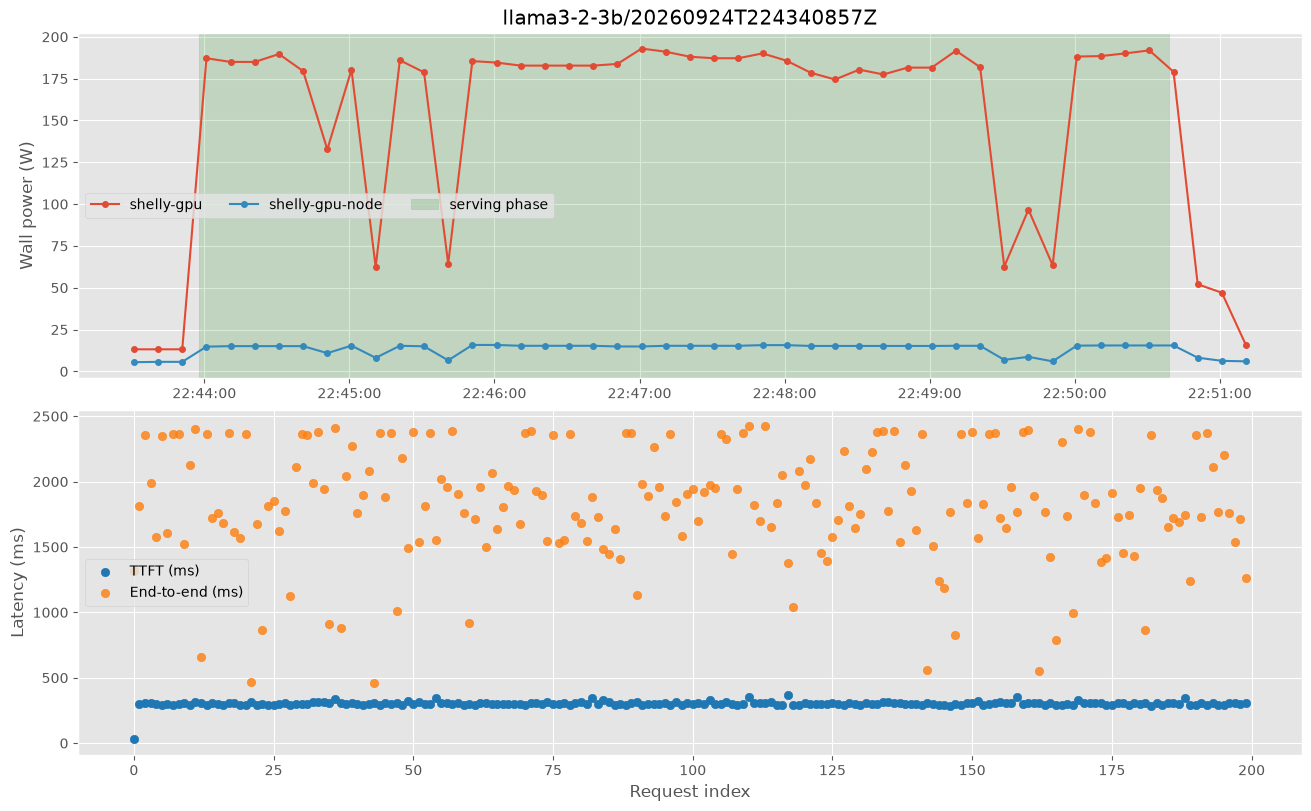

,index,input_tokens,output_tokens,ttft_ms,tpot_ms,e2el_ms
count,200.000000,200.0,200.000000,200.000000,200.000000,200.000000
mean,99.500000,280.0,93.950000,302.011174,16.338016,1821.509921
std,57.879185,0.0,27.210652,22.584986,0.142986,443.149059
min,0.000000,280.0,10.000000,30.508810,16.004631,461.696116
25%,49.750000,280.0,80.750000,295.224306,16.254334,1583.748162
50%,99.500000,280.0,95.000000,300.888604,16.330845,1832.083318
75%,149.250000,280.0,116.500000,307.412034,16.399069,2185.899712
max,199.000000,280.0,128.000000,364.916783,17.157927,2429.058504


In [ ]:
def inspect_run(key):
  run = runs[key]
  meta, bench, power = run["meta"], run["bench"], run["power"]
  fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
  ax = axes[0]
  for sensor in PROMETHEUS_LABELS:
    frame = power.loc[power["sensor"] == sensor]
    if not frame.empty:
      ax.plot(pd.to_datetime(frame["epoch"], unit="s", utc=True), frame["watts"],
        "o-", label=sensor, ms=4)
  def mark(a, b, label, color):
    if np.isfinite(as_float(a)) and np.isfinite(as_float(b)):
      ax.axvspan(pd.to_datetime(a, unit="s", utc=True),
        pd.to_datetime(b, unit="s", utc=True), color=color, alpha=0.16, label=label)
  prep = meta.get("model_preparation", {})
  mark(prep.get("cold_load_start_epoch"), prep.get("cold_load_end_epoch"), "cold load", "red")
  start, end = phase(meta, bench)
  mark(start, end, "serving phase", "green")
  ax.set(title=key, ylabel="Wall power (W)")
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=__import__("datetime").timezone.utc))
  ax.legend(ncol=4)
  trace = requests.loc[requests["run"] == key]
  axes[1].scatter(trace["index"], trace["ttft_ms"], label="TTFT (ms)", color="tab:blue")
  axes[1].scatter(trace["index"], trace["e2el_ms"], label="End-to-end (ms)",
    color="tab:orange", alpha=0.8)
  axes[1].set(xlabel="Request index", ylabel="Latency (ms)")
  axes[1].legend()
  plt.show()


SELECTED_RUN = selected.index[1]  # Change to another run key from the selected table.
inspect_run(SELECTED_RUN)
display(requests.loc[requests["run"] == SELECTED_RUN,
  ["index", "input_tokens", "output_tokens", "ttft_ms", "tpot_ms", "e2el_ms"]].describe())


## 4. Serving behavior across repeated warm runs

Each point is **one run**. Compare repetitions at the same offered rate and concurrency. P95 is calculated within a run, then summarized across runs; individual requests from the same run are not independent repetitions. The campaign alternates model order and rotates load order to reduce time-of-day effects.


,campaign,scenario,model,deployment,hardware,client_host,offered_rps,max_concurrency,runs,p95_ttft_median_ms,p95_e2el_median_ms,tpot_median_ms,throughput_median_rps,output_median_tokens
0,20260924T223519099Z,warm-i1024-o64-rps-0.5-c1,llama3.2:3b,docker,gtx-1070,calculator,0.5,1.0,1,1047.927174,2134.373394,17.287366,0.479613,64.0
1,20260924T223519099Z,warm-i256-o128-rps-0.5-c1,llama3.2:3b,docker,gtx-1070,calculator,0.5,1.0,1,320.942440,2382.629075,16.364562,0.498425,95.0
2,20260924T223519099Z,warm-i256-o64-rps-0.5-c1,llama3.2:3b,docker,gtx-1070,calculator,0.5,1.0,1,303.255047,1334.479557,16.258513,0.498342,64.0


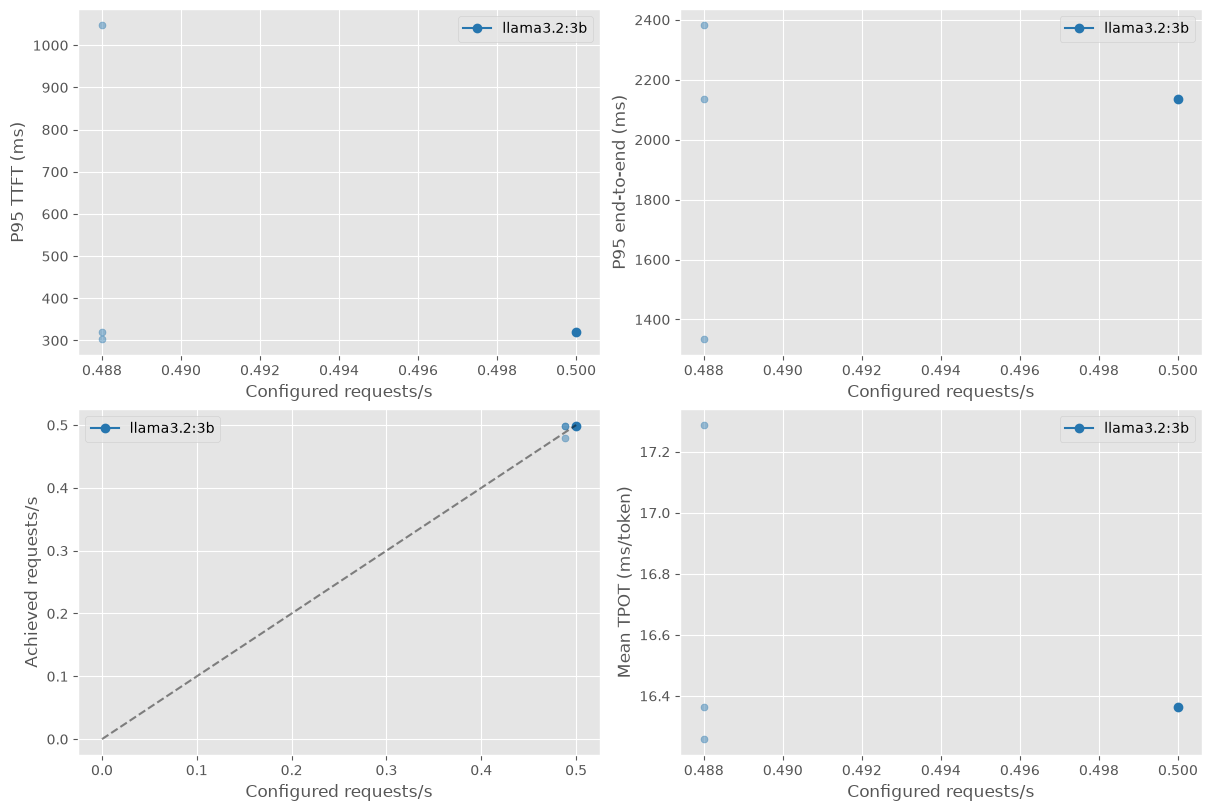

In [ ]:
warm = selected.loc[selected["performance_ok"] & (selected["mode"] == "warm")].copy()
if warm.empty:
  print("No complete warm runs yet. The example cold run belongs in the cold-start section.")
else:
  display(warm.groupby(["campaign", "scenario", "model", "deployment", "hardware",
      "client_host", "offered_rps", "max_concurrency"], dropna=False).agg(
    runs=("completed", "size"), p95_ttft_median_ms=("p95_ttft_ms", "median"),
    p95_e2el_median_ms=("p95_e2el_ms", "median"),
    tpot_median_ms=("mean_tpot_ms", "median"),
    throughput_median_rps=("achieved_rps", "median"),
    output_median_tokens=("output_p50_tokens", "median")
  ).reset_index().sort_values(["offered_rps", "model"]))

def draw_runs(frame, metric, ax, ylabel):
  for model, part in frame.groupby("model"):
    color = LLM_MODEL_COLORS.get(model, "gray")
    for rps, group in part.groupby("offered_rps"):
      x = float(rps) + (-0.012 if model == LLM_MODEL_NAMES[0] else 0.012)
      ax.scatter([x] * len(group), group[metric], color=color, alpha=0.45, s=25)
    med = part.groupby("offered_rps")[metric].median().dropna()
    if not med.empty:
      ax.plot(med.index.to_numpy(float), med.values, "o-", color=color, label=model)
  ax.set(xlabel="Configured requests/s", ylabel=ylabel)
  ax.legend()

if not warm.empty:
  fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
  draw_runs(warm, "p95_ttft_ms", axes[0, 0], "P95 TTFT (ms)")
  draw_runs(warm, "p95_e2el_ms", axes[0, 1], "P95 end-to-end (ms)")
  draw_runs(warm, "achieved_rps", axes[1, 0], "Achieved requests/s")
  draw_runs(warm, "mean_tpot_ms", axes[1, 1], "Mean TPOT (ms/token)")
  axes[1, 0].plot([0, warm["offered_rps"].max()], [0, warm["offered_rps"].max()],
    "k--", alpha=0.45, label="offered = achieved")
  plt.show()


## 5. Output length and tokenizer check

Actual output length affects end-to-end latency and Wh per response. A 128-token cap is not a fixed output length. Token counts from different model tokenizers are not a common unit of semantic work. Always show the length distribution next to token throughput.


,n,input_p50,output_p05,output_p50,output_p95,ttft_p95_ms,e2el_p95_ms
model,,,,,,,
llama3.2:3b,600,280.0,21.75,64.0,128.0,1041.201625,2364.808524


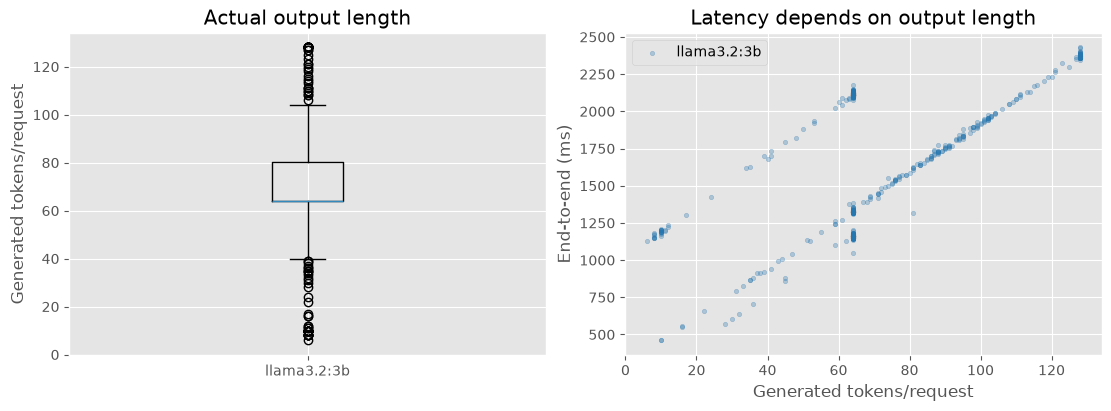

In [ ]:
valid_keys = set(selected.index[selected["performance_ok"]])
detail = requests.loc[requests["run"].isin(valid_keys)].copy()
if not detail.empty:
  display(detail.groupby("model").agg(n=("output_tokens", "size"),
    input_p50=("input_tokens", "median"), output_p05=("output_tokens", lambda x: x.quantile(0.05)),
    output_p50=("output_tokens", "median"), output_p95=("output_tokens", lambda x: x.quantile(0.95)),
    ttft_p95_ms=("ttft_ms", lambda x: x.quantile(0.95)),
    e2el_p95_ms=("e2el_ms", lambda x: x.quantile(0.95))))
  fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
  labels = [m for m in LLM_MODEL_NAMES if m in detail["model"].values]
  axes[0].boxplot([detail.loc[detail["model"] == m, "output_tokens"] for m in labels])
  axes[0].set_xticklabels(labels)
  axes[0].set(ylabel="Generated tokens/request", title="Actual output length")
  for model in labels:
    part = detail.loc[detail["model"] == model]
    axes[1].scatter(part["output_tokens"], part["e2el_ms"], s=10, alpha=0.3,
      label=model, color=LLM_MODEL_COLORS.get(model))
  axes[1].set(xlabel="Generated tokens/request", ylabel="End-to-end (ms)",
    title="Latency depends on output length")
  axes[1].legend()
  plt.show()


## 6. Energy and latency tradeoff

Power is measured at the wall: `shelly-gpu` + `shelly-gpu-node`. `Wh/request` includes the idle share while the serving phase runs. `Wh/1k output tokens` is especially sensitive to early EOS and tokenizer differences. Neither metric subtracts a separately measured idle baseline. Compare only rows marked `energy_ok` and inspect the coverage columns.


,scenario,model,offered_rps,runs,median_power_w,median_wh_per_request,median_wh_per_1k_tokens,median_p95_e2el_ms
0,warm-i1024-o64-rps-0.5-c1,llama3.2:3b,0.5,1,177.332975,0.102706,1.849394,2134.373394
1,warm-i256-o128-rps-0.5-c1,llama3.2:3b,0.5,1,183.149350,0.102071,1.086442,2382.629075
2,warm-i256-o64-rps-0.5-c1,llama3.2:3b,0.5,1,151.907758,0.084674,1.346918,1334.479557


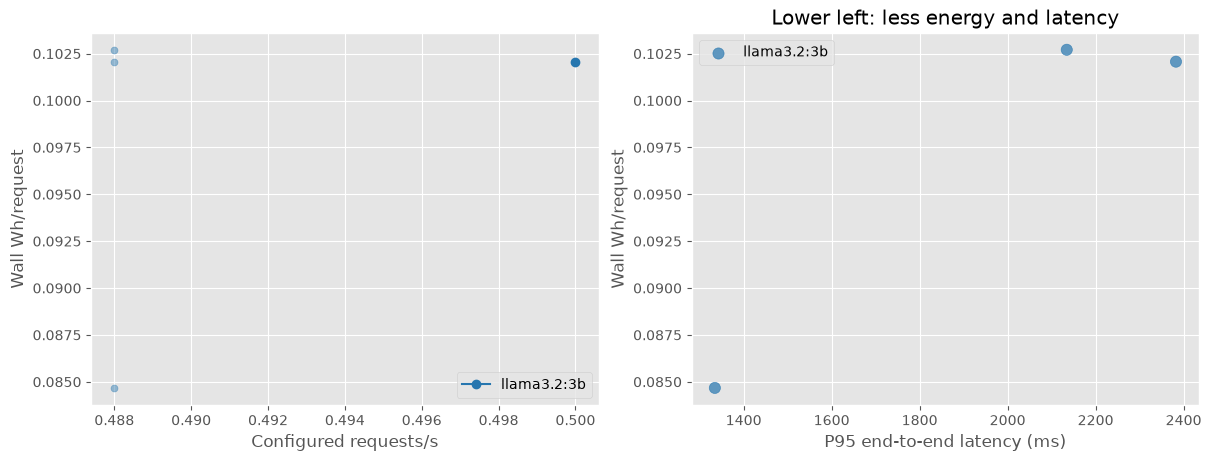

In [ ]:
energy_good = warm.loc[warm["energy_ok"]].copy()
if energy_good.empty:
  print("No power-qualified warm runs. The 23-second example is deliberately excluded.")
else:
  display(energy_good.groupby(["scenario", "model", "offered_rps"], dropna=False).agg(
    runs=("wall_wh", "size"), median_power_w=("mean_wall_w", "median"),
    median_wh_per_request=("wh_per_request", "median"),
    median_wh_per_1k_tokens=("wh_per_1k_output_tokens", "median"),
    median_p95_e2el_ms=("p95_e2el_ms", "median")
  ).reset_index().sort_values(["offered_rps", "model"]))
  fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
  draw_runs(energy_good, "wh_per_request", axes[0], "Wall Wh/request")
  for model, part in energy_good.groupby("model"):
    axes[1].scatter(part["p95_e2el_ms"], part["wh_per_request"],
      c=LLM_MODEL_COLORS.get(model), s=35 + 60 * part["offered_rps"].to_numpy(float),
      alpha=0.7, label=model)
  axes[1].set(xlabel="P95 end-to-end latency (ms)", ylabel="Wall Wh/request",
    title="Lower left: less energy and latency")
  axes[1].legend()
  plt.show()


## 7. Paired model comparison with run-level uncertainty

Pairs require the same campaign, replicate, rate scenario, hardware, client, and deployment. This estimates *differences under the tested workload*, not model quality. Bootstrap the **paired runs**, never the requests inside them. With fewer than five pairs, report observations without a confidence interval.


In [ ]:
def paired_table(frame, metric):
  keys = ["campaign", "replicate", "scenario", "deployment", "hardware",
    "client_host", "offered_rps", "max_concurrency"]
  source = frame.loc[frame["model"].isin(LLM_MODEL_NAMES) & frame["replicate"].notna()]
  if source.empty:
    return pd.DataFrame()
  wide = source.pivot_table(index=keys, columns="model", values=metric, aggfunc="first")
  if not set(LLM_MODEL_NAMES).issubset(wide.columns):
    return pd.DataFrame()
  wide = wide.dropna(subset=list(LLM_MODEL_NAMES))
  wide["gemma_minus_llama"] = wide[LLM_MODEL_NAMES[1]] - wide[LLM_MODEL_NAMES[0]]
  return wide.reset_index()


def paired_interval(values, seed=42):
  values = np.asarray(values, dtype=float)
  values = values[np.isfinite(values)]
  if len(values) < 5:
    return (np.nan, np.nan)
  rng = np.random.default_rng(seed)
  medians = np.median(rng.choice(values, size=(4000, len(values)), replace=True), axis=1)
  return tuple(np.percentile(medians, [2.5, 97.5]))


comparison = []
for metric, frame in [("p95_ttft_ms", warm), ("p95_e2el_ms", warm),
    ("achieved_rps", warm), ("wh_per_request", energy_good)]:
  pairs = paired_table(frame, metric)
  if pairs.empty:
    continue
  for keys, part in pairs.groupby(["campaign", "scenario", "offered_rps"], dropna=False):
    differences = part["gemma_minus_llama"].to_numpy(float)
    low, high = paired_interval(differences)
    comparison.append({"campaign": keys[0], "scenario": keys[1], "rps": keys[2],
      "metric": metric, "pairs": len(part),
      "median_gemma_minus_llama": float(np.median(differences)),
      "bootstrap_low": low, "bootstrap_high": high})
if comparison:
  display(pd.DataFrame(comparison).sort_values(["rps", "metric"]))
else:
  print("No matched warm model pairs with recorded replicate numbers yet.")


No matched warm model pairs with recorded replicate numbers yet.


## 8. Cold-load time, separate from serving

Ollama's empty `/api/generate` request is timed from the client. Its wall time includes network overhead; `cold_load_server_duration_ns` may be absent. At a 10-second power step a load lasting a few seconds cannot support a per-load Wh estimate. Its subsequent vLLM latency belongs to the warm serving measurements.


In [ ]:
cold = selected.loc[selected["mode"] == "cold"].copy()
if cold.empty:
  print("No cold-load runs found.")
else:
  display(cold[["model", "status", "cold_load_s", "gpu_fraction", "quantization"]])
  display(cold.loc[cold["cold_load_s"].notna()].groupby("model")["cold_load_s"].agg(
    ["count", "median", "min", "max"]))
  fig, ax = plt.subplots(figsize=(8, 4))
  for i, model in enumerate(LLM_MODEL_NAMES):
    values = cold.loc[cold["model"] == model, "cold_load_s"].dropna()
    if not values.empty:
      ax.scatter(np.full(len(values), i), values, color=LLM_MODEL_COLORS[model], s=45, alpha=0.7)
      ax.plot([i - 0.18, i + 0.18], [values.median()] * 2, color="black")
  ax.set(xticks=range(len(LLM_MODEL_NAMES)), xticklabels=LLM_MODEL_NAMES, ylabel="Cold load wall time (s)")
  plt.show()


No cold-load runs found.


## 9. Conclusions to fill in after the repeated campaign

1. **Validity:** Are runs complete? Do model digests and quantization stay fixed? Does `gpu_fraction` show that one model spills to CPU? Is the host otherwise idle?
2. **Capacity:** Where does achieved request rate stop following offered rate? Does P95 TTFT or P95 end-to-end increase first?
3. **Token behavior:** How different are actual output lengths and input token counts? Are latency differences still visible at comparable output lengths?
4. **Energy:** For sufficiently long warm phases, how do mean wall watts and Wh/request change with offered rate? Report the two plugs, the scrape step, and that idle draw is included.
5. **Cold start:** Compare the separate load-time distributions. Do not attribute the warm serving P95 to cold start or integrate a 3-second power spike from 10-second data.
6. **Next thesis step:** Repeat a matched Docker/Kubernetes experiment on the same host and client with pinned model digest, quantization, hardware, concurrency, and an application-like fixed prompt set. Add answer-quality checks before calling a model “better.”

The bootstrap interval is descriptive with five repetitions; it does not remove client/network variation, model-output variation, thermal drift, or power sampling uncertainty. Save the run JSON files and the campaign ID with any plot used in the thesis.
